/tmp/ipykernel_370147/3919080464.py:63: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


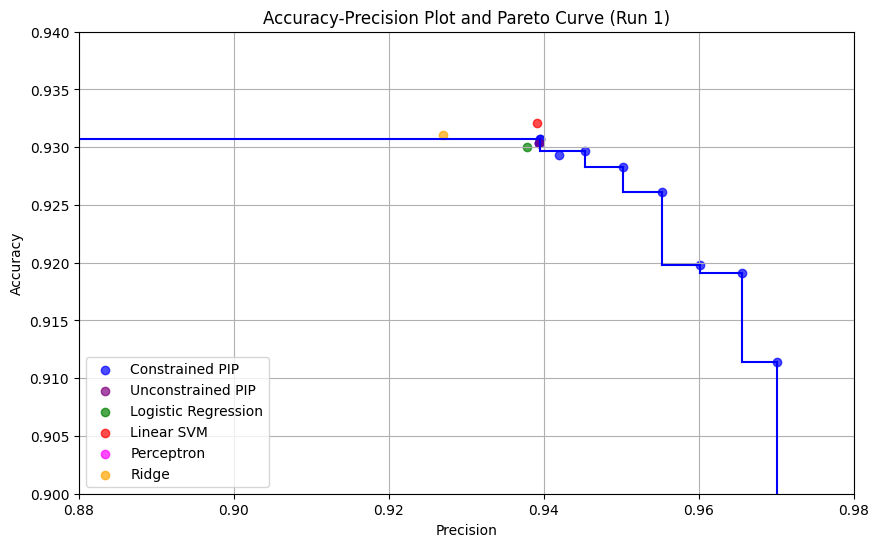

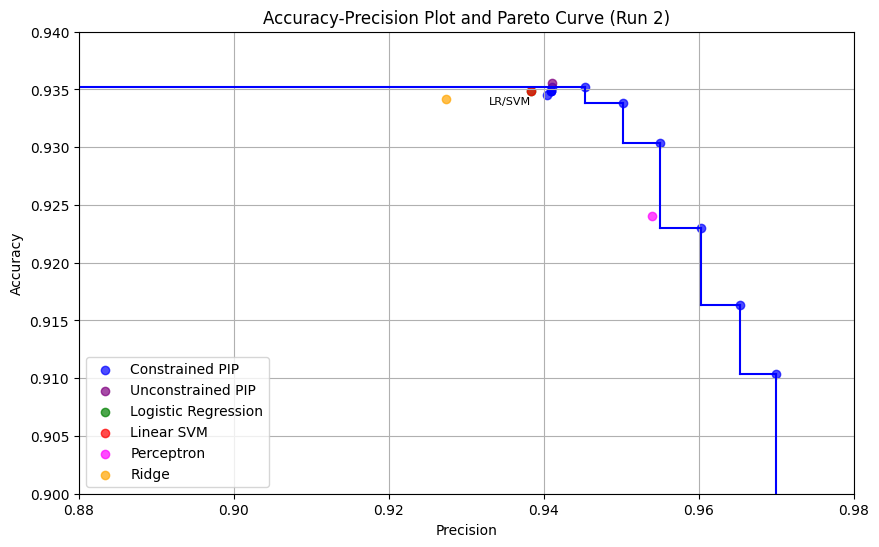

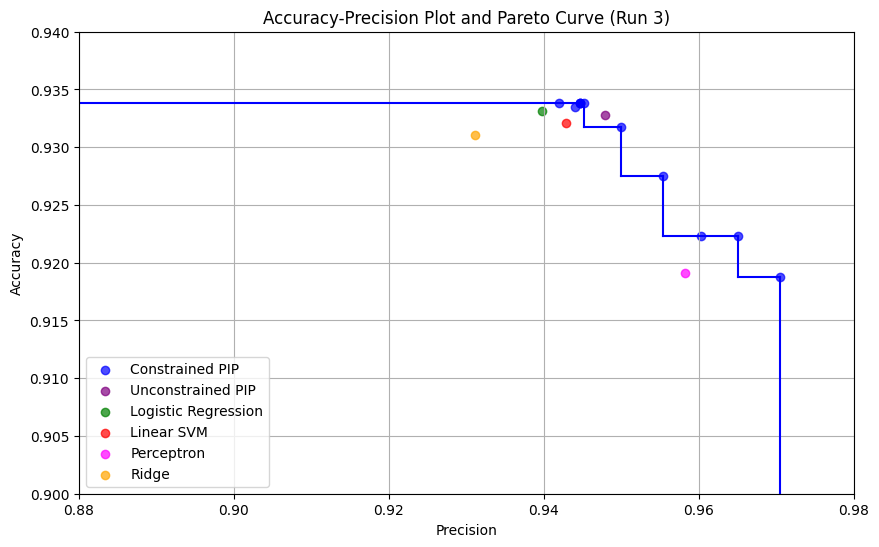

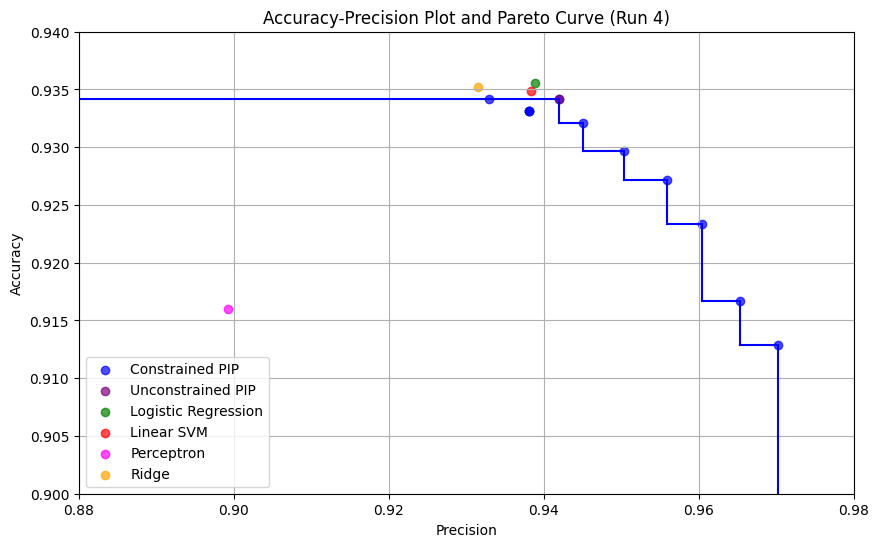

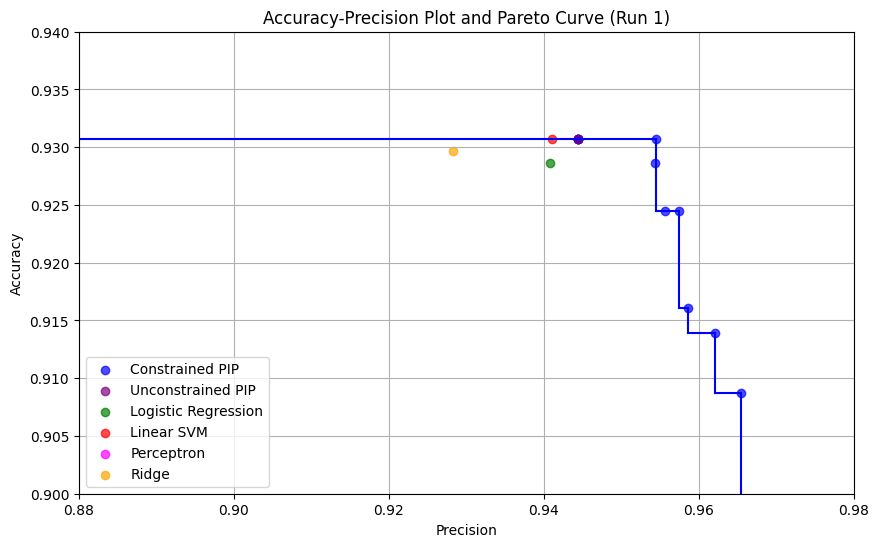

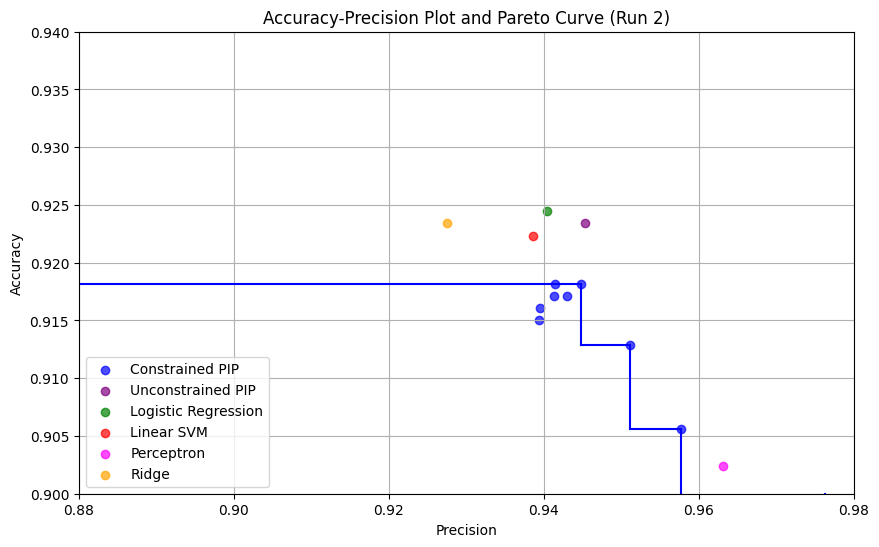

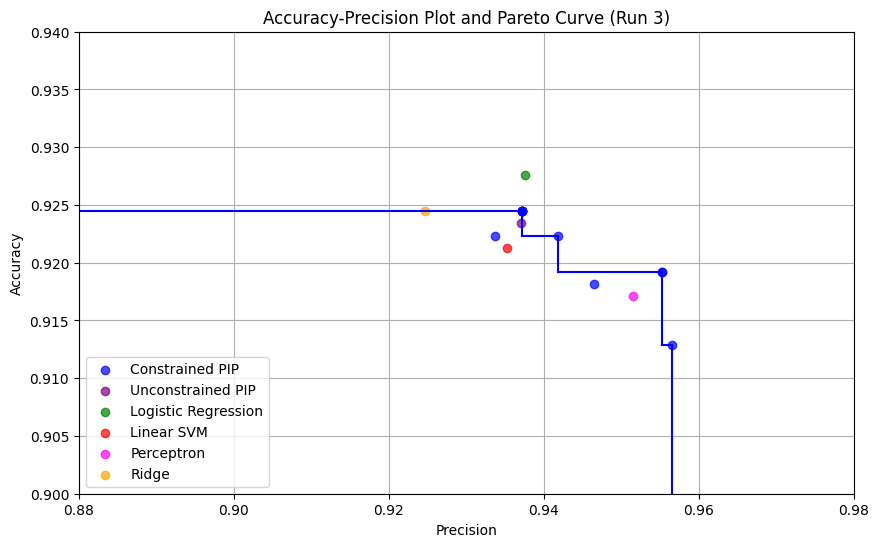

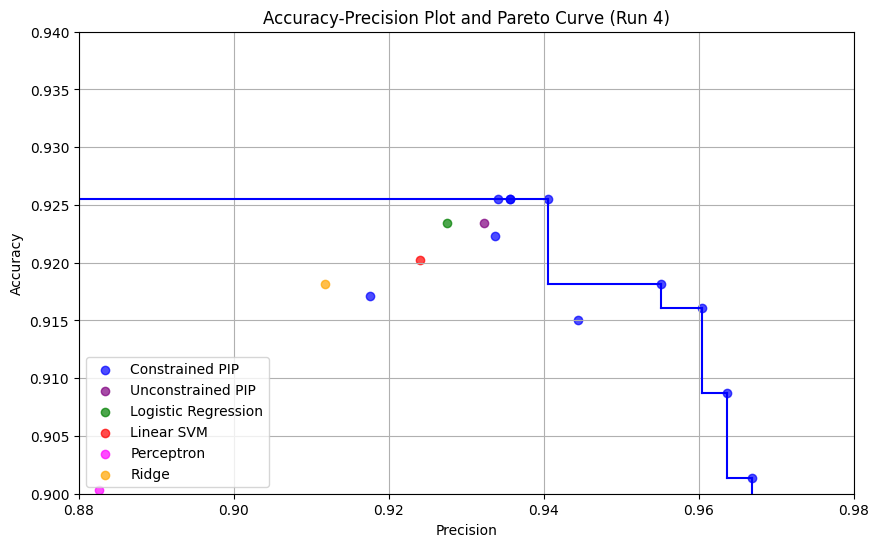

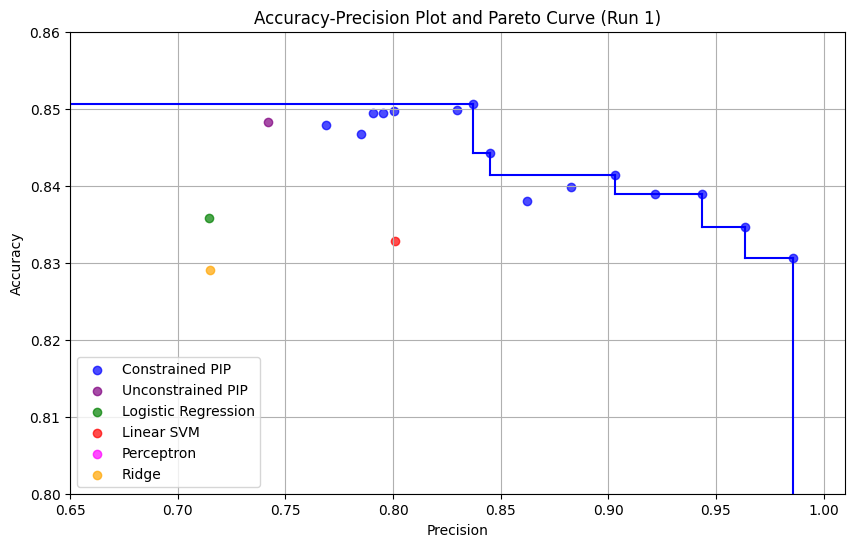

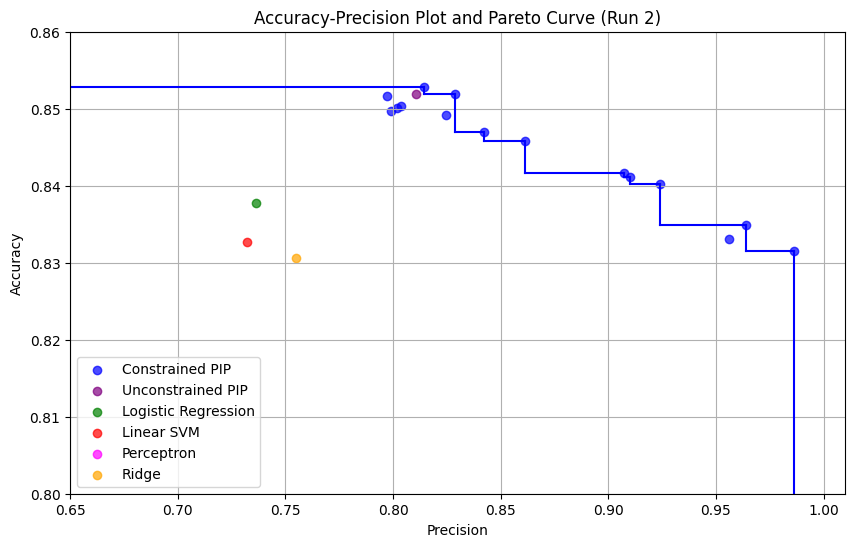

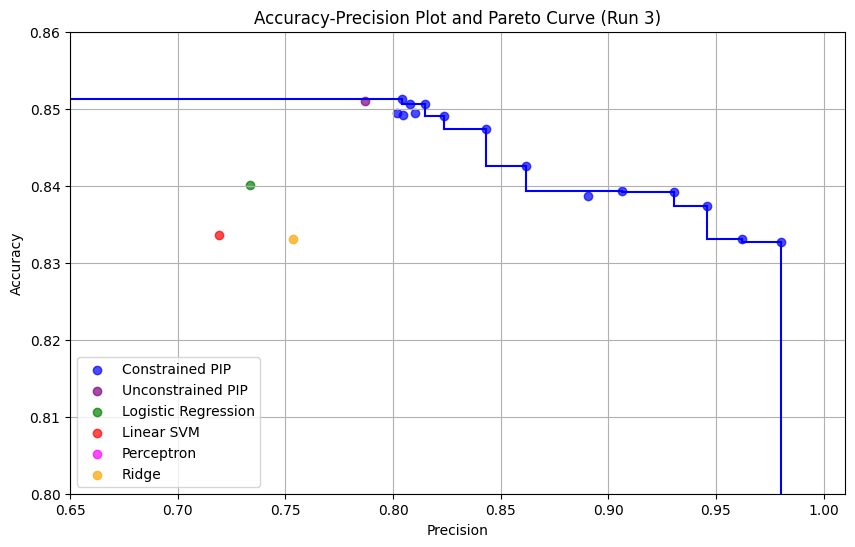

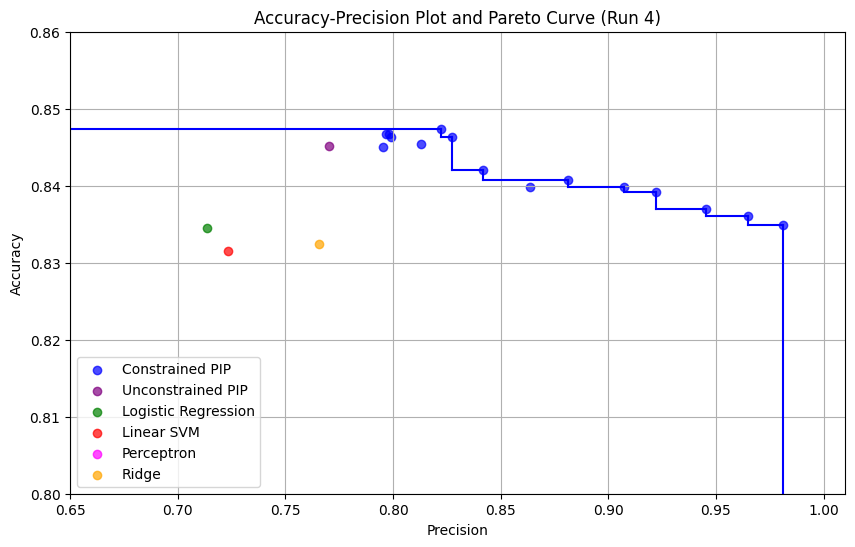

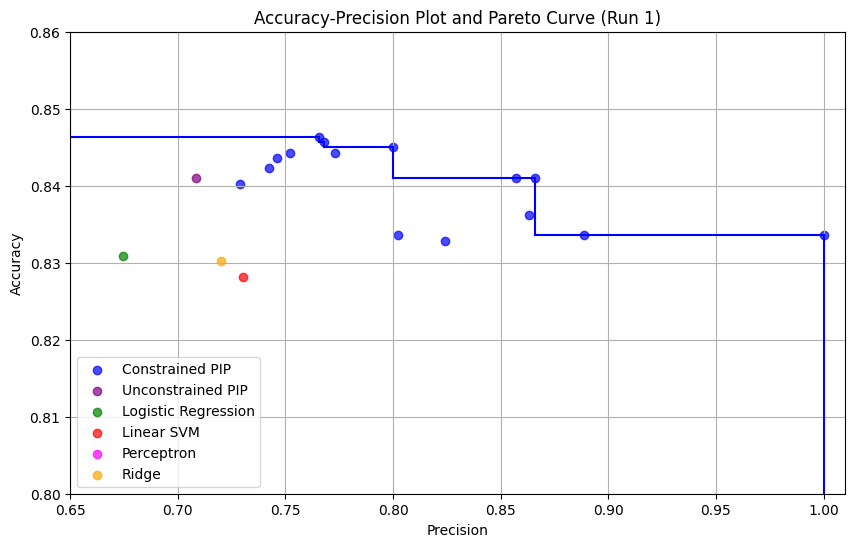

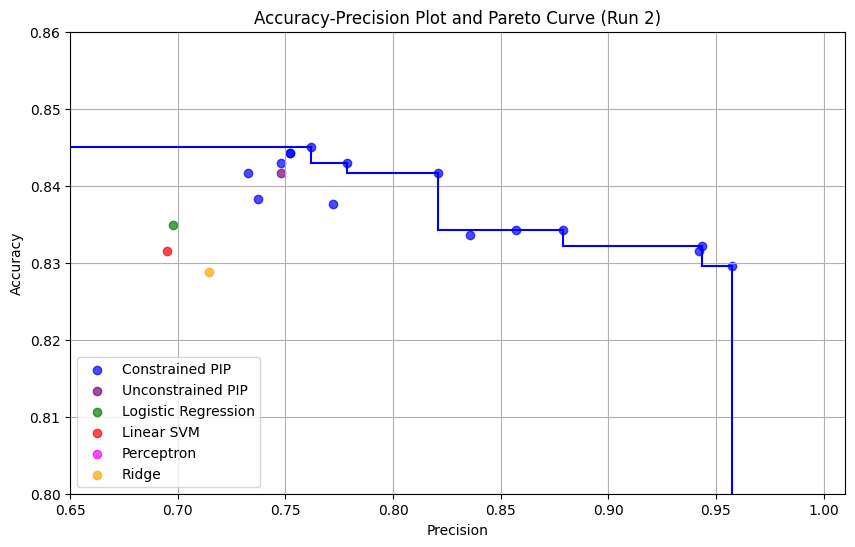

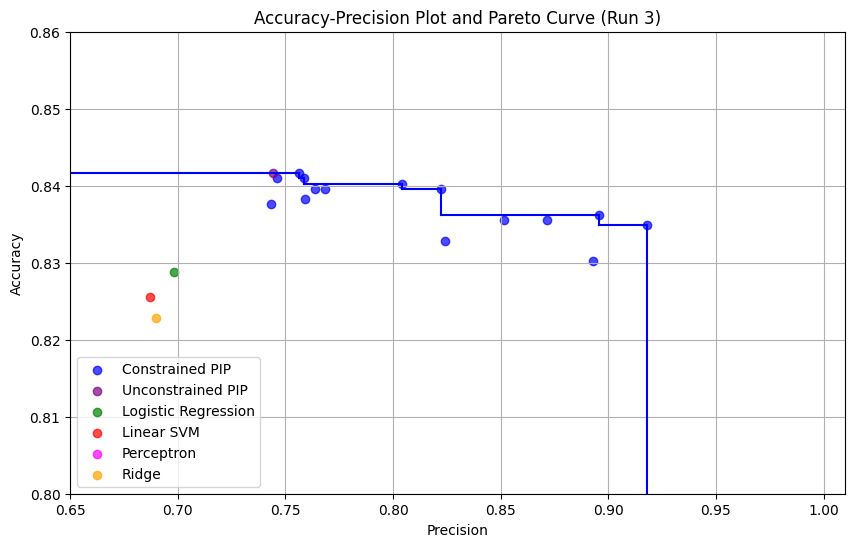

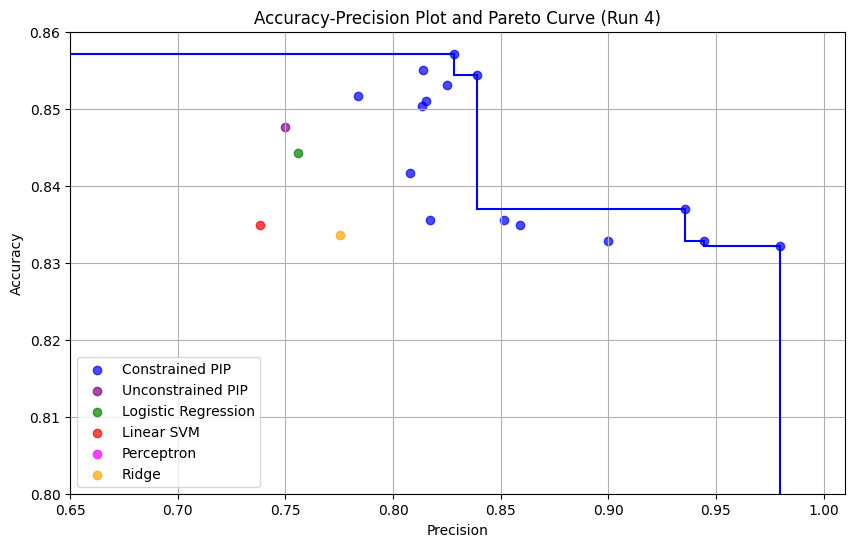

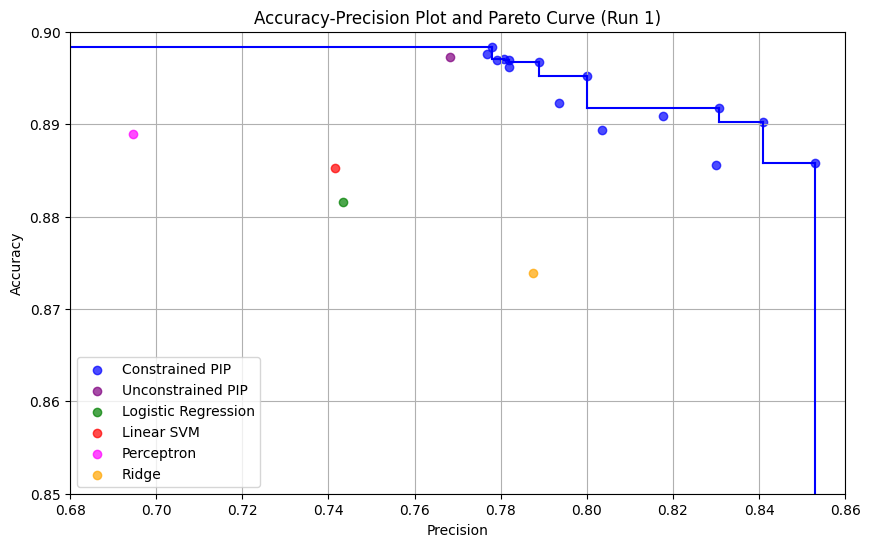

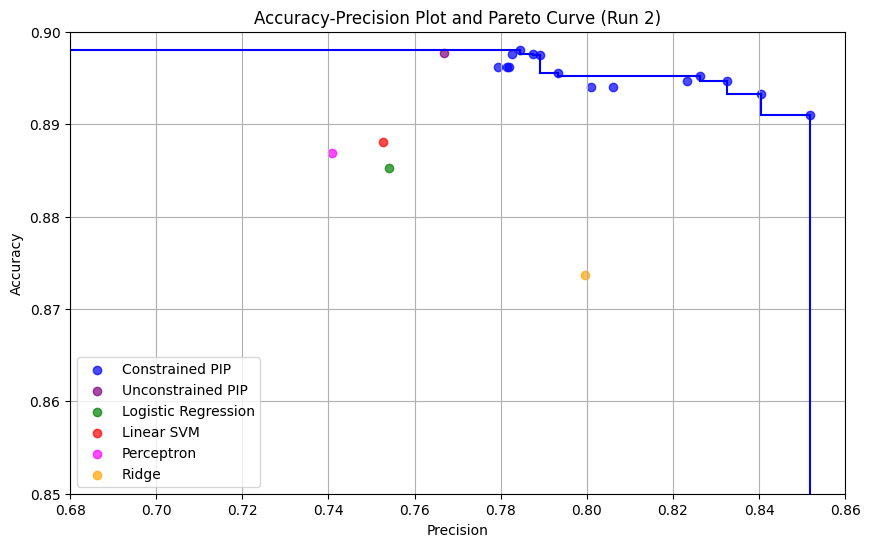

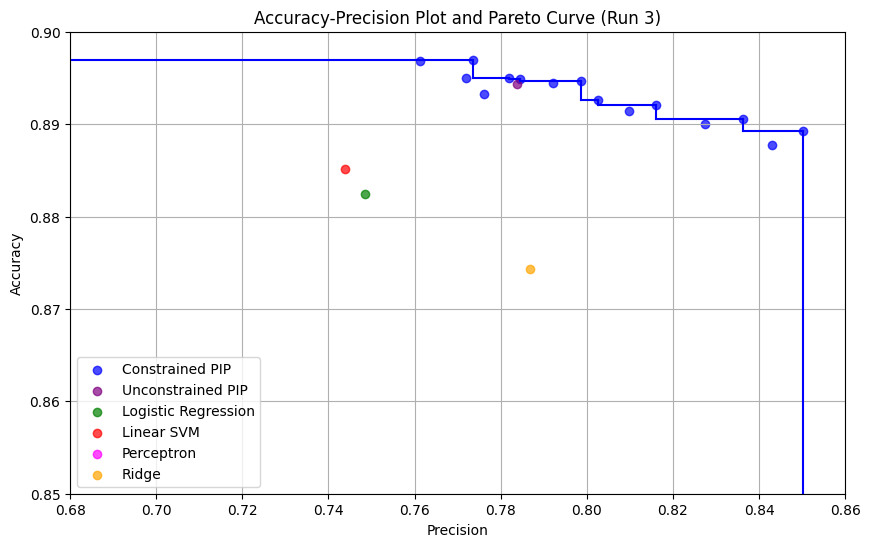

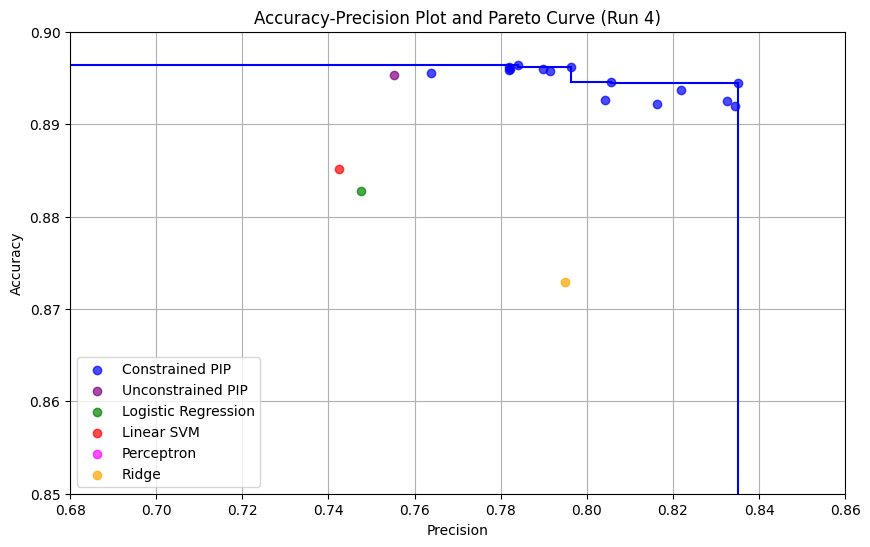

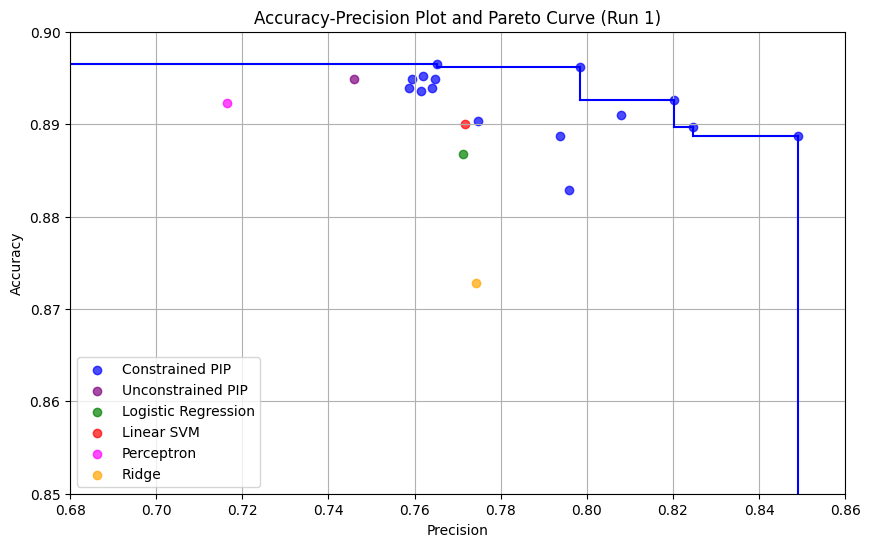

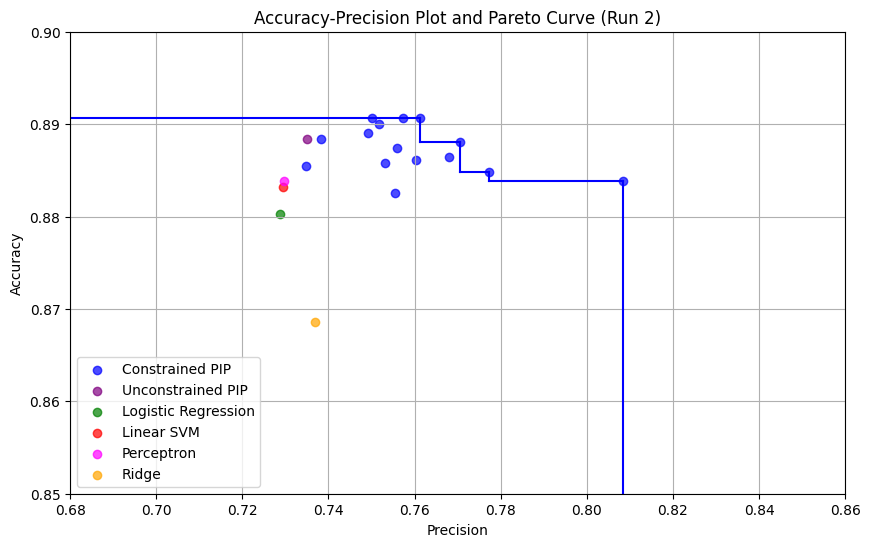

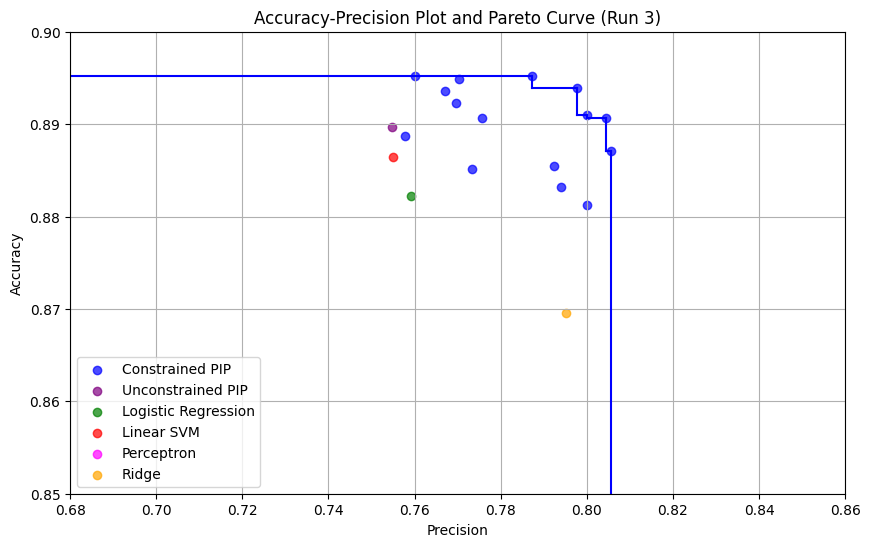

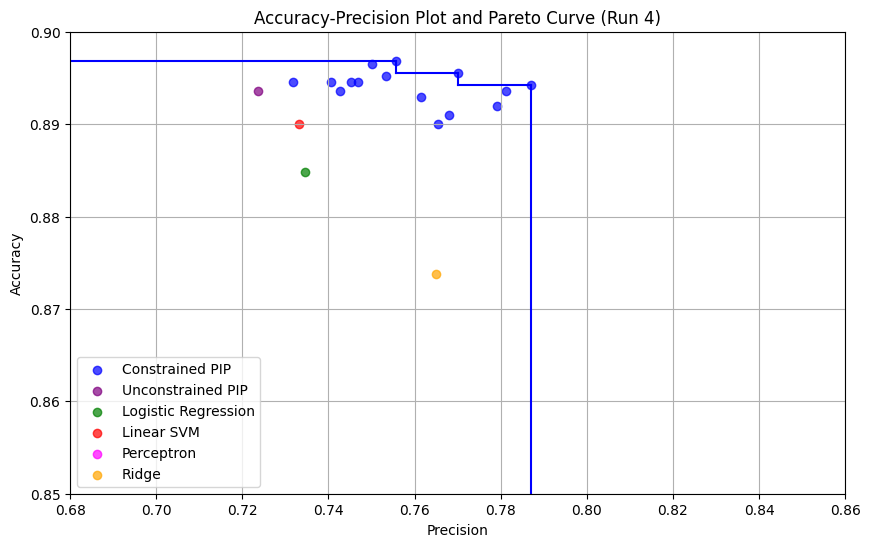

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Loop over all datasets
for dataset in ['rice', 'hmeq', 'ospi']:
    # Loop over training and test results
    for mode in ['train', 'test']:
        # Read the CSV file containing precision-accuracy results
        df = pd.read_csv(f'{dataset}/binary_{dataset}_{mode}_results.csv')

        # Define the plotting order of methods in the scatter plot and legend
        method_order = ['Constrained PIP', 'Unconstrained PIP', 'Logistic Regression', 'Linear SVM', 'Perceptron', 'Ridge']

        # Define the colors corresponding to each method
        color_order = ['blue', 'purple', 'green', 'red', 'magenta', 'orange']
        method_color_map = {method: color_order[i] for i, method in enumerate(method_order)}

        # Set axis limits according to the dataset
        if dataset == 'rice':
            xlim_left = 0.88
            xlim_right = 0.98
            ylim_left = 0.90
            ylim_right = 0.94

        if dataset == 'hmeq':
            xlim_left = 0.65
            xlim_right = 1.01
            ylim_left = 0.80
            ylim_right = 0.86

        if dataset == 'ospi':
            xlim_left = 0.68
            xlim_right = 0.86
            ylim_left = 0.85
            ylim_right = 0.90

        # Generate one plot for each run
        for run in df["run"].unique():
            # Extract data for the current run
            run_df = df[df["run"] == run].copy()

            # Extract results corresponding to Constrained PIP only
            pip_df = run_df[run_df["method"] == "Constrained PIP"].copy()

            # Identify Pareto-optimal points among Constrained PIP solutions
            pareto_points = []
            for i, row in pip_df.iterrows():
                # A point is dominated if another point has:
                # 1) strictly better precision and at least as good accuracy, or
                # 2) at least as good precision and strictly better accuracy
                dominated = ((pip_df["precision"] > row["precision"]) & (pip_df["accuracy"] >= row["accuracy"])) | \
                            ((pip_df["precision"] >= row["precision"]) & (pip_df["accuracy"] > row["accuracy"]))

                # If the point is not dominated, it is Pareto-optimal
                if not dominated.any():
                    pareto_points.append((row["precision"], row["accuracy"]))

            # Convert Pareto-optimal points into a DataFrame and sort by precision
            pareto_df = pd.DataFrame(pareto_points, columns=["precision", "accuracy"])
            pareto_df = pareto_df.sort_values(by=["precision"])

            # Create a new figure for the current run
            plt.figure(figsize=(10, 6))

            # Store scatter handles and labels for legend construction
            handles = []
            labels = []

            # Plot the precision-accuracy points for each method
            for method in method_order:
                group = run_df[run_df["method"] == method]
                sc = plt.scatter(
                    group["precision"],
                    group["accuracy"],
                    label=method,
                    color=method_color_map[method],
                    alpha=0.7
                )

                handles.append(sc)
                labels.append(method)

            # Set title and axis labels
            plt.title(f"Accuracy-Precision Plot and Pareto Curve (Run {run})")
            plt.xlabel("Precision")
            plt.ylabel("Accuracy")

            # Set axis ranges
            plt.xlim(xlim_left, xlim_right)
            plt.ylim(ylim_left, ylim_right)

            # Plot the stepwise Pareto curve for Constrained PIP
            pareto_color = method_color_map["Constrained PIP"]

            # Draw the first horizontal segment from the left boundary to the first Pareto point
            x0, y0 = pareto_df.iloc[0]["precision"], pareto_df.iloc[0]["accuracy"]
            plt.plot([xlim_left, x0], [y0, y0], color=pareto_color)

            # Draw vertical and horizontal step segments between consecutive Pareto points
            for i in range(len(pareto_df) - 1):
                x_curr, y_curr = pareto_df.iloc[i]["precision"], pareto_df.iloc[i]["accuracy"]
                x_next, y_next = pareto_df.iloc[i + 1]["precision"], pareto_df.iloc[i + 1]["accuracy"]

                # Vertical segment
                plt.plot([x_curr, x_curr], [y_curr, y_next], color=pareto_color)

                # Horizontal segment
                plt.plot([x_curr, x_next], [y_next, y_next], color=pareto_color)

            # Draw the last vertical segment down to the lower y-axis boundary
            x_last, y_last = pareto_df.iloc[-1]["precision"], pareto_df.iloc[-1]["accuracy"]
            plt.plot([x_last, x_last], [y_last, ylim_left], color=pareto_color)

            # Annotate the overlapping LR/SVM point for a specific case
            if dataset == 'rice' and mode == 'train' and run == 2:
                lr_points = run_df[run_df["method"] == "Logistic Regression"]
                for i, row in lr_points.iterrows():
                    plt.annotate(
                        'LR/SVM',
                        (row["precision"], row["accuracy"]),
                        textcoords="offset points",
                        xytext=(0, -10),
                        ha='right',
                        fontsize=8,
                        color='black'
                    )

            # Add legend and grid
            plt.legend(handles=handles, labels=labels, loc='lower left')
            plt.grid(True)

            # Save the figure
            plt.savefig(f'{dataset}/{dataset}_{mode}_run_{run}.png')